# Modelo Lasso

Lasso (least absolute shrinkage and selection operator, por sus siglas en inglés), es un método de análisis de regresión que realiza selección de variables y regularización para mejorar la exactitud e interpretabilidad del modelo estadístico producido por este.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
names=['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 
'model_year', 'origin', 'car_name'] 

df = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data-original", 
    sep=r'\s+', 
    header=None, 
    names=names
    )

df.set_index('car_name', inplace=True)
df.dropna(inplace=True)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
car_name,,,,,,,,
chevrolet chevelle malibu,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1.0
buick skylark 320,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1.0
plymouth satellite,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1.0
amc rebel sst,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1.0
ford torino,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, chevrolet chevelle malibu to chevy s-10
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    float64
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    float64
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    float64
 7   origin        392 non-null    float64
dtypes: float64(8)
memory usage: 27.6+ KB


In [ ]:
# Extraccion de matrices de caracteristicas y objetivo, y division de los datos en 
# entrenamiento y prueba
from sklearn.model_selection import train_test_split

X = df.drop(['mpg'], axis=1)
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    random_state=1, 
    train_size=0.7
    )

print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (274, 7)
Tamaño del conjunto de prueba es: (118, 7)


In [5]:
# prompt: don't display warnings
import warnings

warnings.filterwarnings("ignore")

El método Lasso asume que los coeficientes de los modelos lineales son *sparse*, es decir, que solo algunos de ellos son no cero.

La cantidad de coeficientes que se harán cero depende del parámetro $λ$, que determina que tanto se penalizará el tamaño de estos.

In [6]:
from sklearn.linear_model import Lasso

coeficientes = []
alphas = [0, 0.01, 0.1, 1, 10, 100]
for alpha in alphas:
  model = Lasso(alpha = alpha)
  model.fit(X_train, y_train)
  coeficientes.append(model.coef_)
df_lasso = pd.DataFrame(
  data=coeficientes, 
  columns=model.feature_names_in_, 
  index=alphas
  )
  
df_lasso

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0.00,-0.205978,0.019639,-0.001616,-0.007283,0.281866,0.742798,1.380904
0.01,-0.162993,0.018682,-0.001526,-0.007278,0.278138,0.742125,1.349825
0.10,-0.000000,0.013719,-0.001453,-0.007202,0.243372,0.735303,1.090565
1.00,0.000000,0.001110,-0.011278,-0.006381,0.000000,0.656647,0.000000
10.00,-0.000000,-0.006816,-0.015485,-0.006053,0.000000,0.000000,0.000000
100.00,-0.000000,-0.000000,-0.000000,-0.007308,0.000000,0.000000,0.000000


<Figure size 640x480 with 0 Axes>

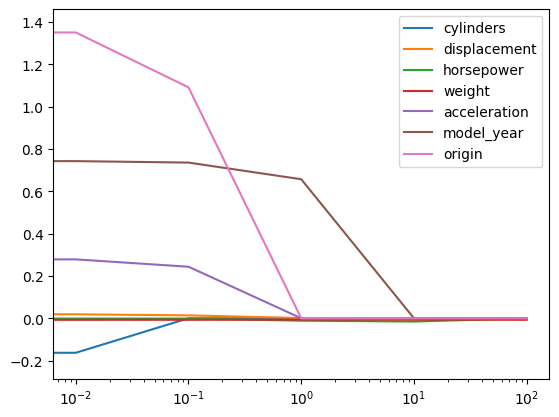

In [7]:
plt.figure()
df_lasso.plot.line()
plt.xscale('log')
plt.show()

Esto comportamiento es diferente al de los modelos Ridge, que a medida que aumenta $\lambda$ disminuye el tamaño de los coeficientes, **pero nunca se hacen cero**.

In [8]:
from sklearn.linear_model import Ridge

coeficientes = []
alphas = [0, 0.01, 0.1, 1, 10, 100]
for alpha in alphas:
  model = Ridge(alpha = alpha)
  model.fit(X_train, y_train)
  coeficientes.append(model.coef_)

df_ridge = pd.DataFrame(
  data=coeficientes, 
  columns=model.feature_names_in_, 
  index=alphas
  )

df_ridge

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0.00,-0.205978,0.019639,-0.001616,-0.007283,0.281866,0.742798,1.380904
0.01,-0.205931,0.019637,-0.001615,-0.007283,0.281859,0.742796,1.380767
0.10,-0.205511,0.019621,-0.001607,-0.007283,0.281799,0.742781,1.379536
1.00,-0.201387,0.019464,-0.001525,-0.007283,0.281198,0.742636,1.367352
10.00,-0.166480,0.018068,-0.000823,-0.007283,0.275465,0.741105,1.256603
100.00,-0.049737,0.011660,0.001060,-0.007210,0.234215,0.722772,0.697041


<Figure size 640x480 with 0 Axes>

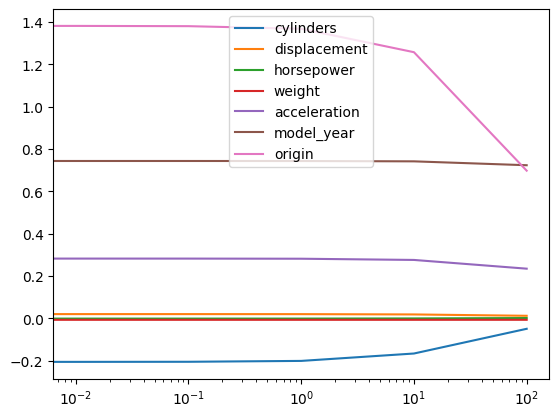

In [9]:
plt.figure()
df_ridge.plot.line()
plt.xscale('log')
plt.show()

## Lasso frente a los otros modelos de regresión lineal

Como modelo predictivo, Lasso suele dar mejores resultados que OLS, pero un poco peores que Ridge.

In [10]:
df['inv_displacement'] = 1 / df['displacement']
df['inv_weight'] = 1 / df['weight']
df['inv_horsepower'] = 1 / df['horsepower']
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,inv_displacement,inv_weight,inv_horsepower
car_name,,,,,,,,,,,
chevrolet chevelle malibu,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1.0,0.003257,0.000285,0.007692
buick skylark 320,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1.0,0.002857,0.000271,0.006061
plymouth satellite,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1.0,0.003145,0.000291,0.006667
amc rebel sst,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1.0,0.003289,0.000291,0.006667
ford torino,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1.0,0.003311,0.000290,0.007143


In [ ]:
# Extraccion de matrices de caracteristicas y objetivo, y division de los datos en 
# entrenamiento y prueba
X = df.drop(['mpg'], axis=1)
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    random_state=1, 
    train_size=0.7
    )

print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (274, 10)
Tamaño del conjunto de prueba es: (118, 10)


En primer lugar, vamos a entrenar un modelo de regresión lineal OLS, haciendo una normalización previa de las características del modelo:

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train, y_train)
print(f'Error de entrenamiento: {root_mean_squared_error(y_train, model.predict(X_train)):.3f}')  # noqa: E501
print(f'Error de prueba: {root_mean_squared_error(y_test, model.predict(X_test)):.3f}')

Error de entrenamiento: 2.873
Error de prueba: 2.991


Los coeficientes de este modelo son:

In [13]:
pesos = pd.DataFrame(data=model.coef_, index=X.columns, columns=['Coeficiente'])
pesos.loc['intercepto'] = model.intercept_
pesos

,Coeficiente
cylinders,-1.520635
displacement,1.838827
horsepower,5.754003
weight,-3.718000
acceleration,-0.861237
model_year,9.311892
origin,1.609754
inv_displacement,0.905101
inv_weight,12.567622
inv_horsepower,13.342240


Ahora vamos a sintonizar y entrenar un modelo Ridge, con las características ya normalizadas:

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler

param_grid = {'alpha': np.logspace(-6,-3)}
model = GridSearchCV(
    estimator=Ridge(), # modelo a sintonizar
    param_grid=param_grid, # valores de hiperparámetros a sintonizar
    scoring='neg_root_mean_squared_error', # métrica de evaluación, en este caso RMSE
    cv=5, # número de particiones para validación cruzada, por defcto es 5
    refit=True # reentrena el modelo con los mejores hiperparámetros
    )

model.fit(X_train, y_train)
print(f'Menor error de validación: {-model.best_score_:.3f} con lambda: {model.best_params_}')  # noqa: E501
print(f'Error de entrenamiento: {root_mean_squared_error(y_train, model.best_estimator_.predict(X_train)):.3f}')  # noqa: E501
print(f'Error de prueba: {root_mean_squared_error(y_test, model.best_estimator_.predict(X_test)):.3f}')  # noqa: E501

Menor error de validación: 3.103 con lambda: {'alpha': np.float64(0.001)}
Error de entrenamiento: 2.873
Error de prueba: 2.991


Los coeficientes de este modelo son:

In [15]:
pesos = pd.DataFrame(
    data=model.best_estimator_.coef_, 
    index=X.columns, 
    columns=['Coeficiente']
    )

pesos.loc['intercepto'] = model.best_estimator_.intercept_
pesos

,Coeficiente
cylinders,-1.518839
displacement,1.848995
horsepower,5.737772
weight,-3.727794
acceleration,-0.860213
model_year,9.311134
origin,1.609637
inv_displacement,0.918202
inv_weight,12.554236
inv_horsepower,13.328841


Por último, vamos a entrenar un modelo Lasso:

In [16]:
from sklearn.linear_model import Lasso

param_grid = {'alpha': np.logspace(-6,-3)}

model = GridSearchCV(
    estimator=Lasso(), 
    param_grid=param_grid, 
    scoring='neg_root_mean_squared_error'
    )

model.fit(X_train, y_train)
print(f'Menor error de validación: {-model.best_score_:.3f} con lambda: {model.best_params_}')  # noqa: E501
print(f'Error de entrenamiento: {root_mean_squared_error(y_train, model.best_estimator_.predict(X_train)):.3f}')  # noqa: E501
print(f'Error de prueba: {root_mean_squared_error(y_test, model.best_estimator_.predict(X_test)):.3f}')  # noqa: E501


Menor error de validación: 3.096 con lambda: {'alpha': np.float64(0.001)}
Error de entrenamiento: 2.873
Error de prueba: 2.994


Los coeficientes de este modelo son:

In [17]:
pesos = pd.DataFrame(
    data=model.best_estimator_.coef_, 
    index=X.columns, 
    columns=['Coeficiente']
    )

pesos.loc['intercepto'] = model.best_estimator_.intercept_
pesos

,Coeficiente
cylinders,-1.377653
displacement,1.301713
horsepower,5.376253
weight,-2.956957
acceleration,-0.847238
model_year,9.283247
origin,1.599375
inv_displacement,0.687824
inv_weight,13.182152
inv_horsepower,12.976238


Nótese como varios coeficientes se hacen cero, lo que implica que las características asociadas se eliminan del modelo.

## Lasso como método de selección de características

Lasso podría usarse como método de **selección de características**.

Usándolo así, sería un paso previo al de creación del modelo predictivo.

In [18]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
pesos_lasso = pd.DataFrame(data=lasso.coef_, index=X.columns, columns=['Coeficiente'])
pesos_lasso

,Coeficiente
cylinders,-1.194201
displacement,-0.000000
horsepower,-0.000000
weight,-0.000000
acceleration,0.000000
model_year,8.284703
origin,1.421726
inv_displacement,0.811233
inv_weight,14.761681
inv_horsepower,5.908901


In [19]:
selected_features = pesos_lasso[pesos_lasso['Coeficiente'] != 0].index
selected_features

Index(['cylinders', 'model_year', 'origin', 'inv_displacement', 'inv_weight',
       'inv_horsepower'],
      dtype='object')

In [20]:
X_sel = df[selected_features]

X_train_sel, X_test_sel, y_train, y_test = train_test_split(
    X_sel, y, 
    random_state=1, 
    train_size=0.7
    )

scaler = MinMaxScaler()
X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel = scaler.transform(X_test_sel)

param_grid = {'alpha': np.logspace(-4,2)}
model = GridSearchCV(Ridge(), param_grid, scoring='neg_root_mean_squared_error', cv=5)
model.fit(X_train_sel, y_train)
print(f'Menor error de validación: {-model.best_score_:.3f} con lambda: {model.best_params_}')  # noqa: E501
print(f'Error de entrenamiento: {root_mean_squared_error(y_train, model.best_estimator_.predict(X_train_sel)):.3f}')  # noqa: E501
print(f'Error de prueba: {root_mean_squared_error(y_test, model.best_estimator_.predict(X_test_sel)):.3f}')  # noqa: E501

Menor error de validación: 3.074 con lambda: {'alpha': np.float64(0.6250551925273969)}
Error de entrenamiento: 2.919
Error de prueba: 3.110


In [21]:
pesos = pd.DataFrame(
    data=model.best_estimator_.coef_, 
    index=X_sel.columns, 
    columns=['Coeficiente']
    )

pesos.loc['intercepto'] = model.best_estimator_.intercept_
pesos

,Coeficiente
cylinders,-0.516272
model_year,8.778658
origin,1.569187
inv_displacement,2.957408
inv_weight,12.600934
inv_horsepower,8.228602
intercepto,9.608968
